In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Đọc file
orders = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dữ liệu/Silver_Data/ORDERS.csv")

order_item = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dữ liệu/Silver_Data/ORDER_ITEM.csv")

product = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dữ liệu/Silver_Data/product.csv")

promotion = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dữ liệu/Silver_Data/promotion.csv")

In [ ]:
# kiểm tra dữ liệu ORDER
print("ORDERS")
print("Số dòng:", len(orders))
print("Số cột:", len(orders.columns))

orders.info()
print(orders["order_status"].value_counts())

ORDERS
Số dòng: 646945
Số cột: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   order_id           646945 non-null  int64 
 1   order_date         646945 non-null  object
 2   order_status       646945 non-null  object
 3   device_type        646945 non-null  object
 4   order_source       646945 non-null  object
 5   customer_id        646945 non-null  int64 
 6   sales_employee_id  646945 non-null  object
 7   zip                646945 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 39.5+ MB
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [ ]:
# kiểm tra dữ liệu ORDER_ITEM
print("ORDER_ITEM")
print("Số dòng:", len(order_item))
print("Số cột:", len(order_item.columns))

order_item.info()
# kiểm tra missing
print("Missing ORDERS:")
print(orders.isnull().sum())

print("\nMissing ORDER_ITEM:")
print(order_item.isnull().sum())

ORDER_ITEM
Số dòng: 714669
Số cột: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   product_id       714669 non-null  int64  
 1   order_id         714669 non-null  int64  
 2   promo_id         276316 non-null  object 
 3   quantity         714669 non-null  int64  
 4   unit_price       714669 non-null  float64
 5   discount_amount  714669 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 32.7+ MB
Missing ORDERS:
order_id             0
order_date           0
order_status         0
device_type          0
order_source         0
customer_id          0
sales_employee_id    0
zip                  0
dtype: int64

Missing ORDER_ITEM:
product_id              0
order_id                0
promo_id           438353
quantity                0
unit_price              0
discount_amount         0
dtype: int64


In [ ]:
# Kiểm tra dữ liệu số
print(order_item[
    ["quantity", "unit_price", "discount_amount"]
].describe())

# kiểm giá trị âm
print("Quantity âm:",
      (order_item["quantity"] < 0).sum())

print("Unit price âm:",
      (order_item["unit_price"] < 0).sum())

print("Discount âm:",
      (order_item["discount_amount"] < 0).sum())

            quantity     unit_price  discount_amount
count  714669.000000  714669.000000    714669.000000
mean        4.495988    5114.690157      1048.887415
std         2.290143    3774.817912      2280.530606
min         1.000000     392.570000         0.000000
25%         2.000000    1906.890000         0.000000
50%         4.000000    4257.770000         0.000000
75%         6.000000    7273.760000       967.630000
max         8.000000   43056.000000     35235.470000
Quantity âm: 0
Unit price âm: 0
Discount âm: 0


In [ ]:
# làm sạch và chuẩn bị dữ liệu
# chuyển ngày
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)
print(
    "Ngày không hợp lệ:",
    orders["order_date"].isna().sum()
)

Ngày không hợp lệ: 0


In [ ]:
# Kiểm tra khóa trước khi join
print(
    "ORDER_ITEM không tìm thấy order_id:",
    (~order_item["order_id"].isin(orders["order_id"])).sum()
)

print(
    "ORDER_ITEM không tìm thấy product_id:",
    (~order_item["product_id"].isin(product["product_id"])).sum()
)

ORDER_ITEM không tìm thấy order_id: 0
ORDER_ITEM không tìm thấy product_id: 0


In [ ]:
# Lọc đơn hàng delivered
orders_delivered = orders[
    orders["order_status"] == "delivered"
].copy()
print(
    "Số đơn delivered:",
    len(orders_delivered)
)

Số đơn delivered: 516716


In [ ]:
# JOIN ORDERS với ORDER_ITEM
sales = order_item.merge(
    orders_delivered[
        ["order_id", "order_date"]
    ],
    on="order_id",
    how="inner"
)
print("Số dòng sau JOIN:", len(sales))
print(sales.head())

Số dòng sau JOIN: 570887
   product_id  order_id promo_id  quantity  unit_price  discount_amount  \
0        2400         1      NaN         7     1138.22              0.0   
1         396         3      NaN         3    11220.33              0.0   
2         635         4      NaN         5    10639.25              0.0   
3        1935         6      NaN         1     1597.84              0.0   
4        1934         7      NaN         6     1633.49              0.0   

  order_date  
0 2012-07-04  
1 2012-07-04  
2 2012-07-04  
3 2012-07-06  
4 2012-07-06  


<h1>Measure

In [ ]:
sales["actual_revenue"] = (
    sales["quantity"] * sales["unit_price"]
    - sales["discount_amount"]
)
print(
    sales["actual_revenue"].describe()
)
total_revenue = sales["actual_revenue"].sum()

print(
    f"Tổng doanh thu thực tế: {total_revenue:,.2f}"
)

count    570887.000000
mean      21927.589798
std       21687.548523
min         424.260000
25%        6035.225000
50%       14529.400000
75%       30605.260000
max      331570.400000
Name: actual_revenue, dtype: float64
Tổng doanh thu thực tế: 12,518,175,957.20


In [ ]:
# Tạo tháng
sales["month"] = (
    sales["order_date"]
    .dt.to_period("M")
)

<h1>Metric 1 — Monthly Revenue

In [ ]:
monthly_revenue = (
    sales
    .groupby("month")["actual_revenue"]
    .sum()
    .reset_index()
)
monthly_revenue = monthly_revenue.rename(
    columns={
        "actual_revenue": "monthly_revenue"
    }
)
print(monthly_revenue.head(10))

     month  monthly_revenue
0  2012-07     1.049841e+08
1  2012-08     1.272702e+08
2  2012-09     1.021076e+08
3  2012-10     8.725036e+07
4  2012-11     7.720754e+07
5  2012-12     9.295272e+07
6  2013-01     7.355969e+07
7  2013-02     8.527919e+07
8  2013-03     1.137209e+08
9  2013-04     1.522584e+08


<h1>Metric 2 — MoM Growth

In [ ]:
monthly_revenue["previous_revenue"] = (
    monthly_revenue["monthly_revenue"].shift(1)
)
monthly_revenue["mom_growth"] = (
    (
        monthly_revenue["monthly_revenue"]
        - monthly_revenue["previous_revenue"]
    )
    / monthly_revenue["previous_revenue"]
) * 100
print(monthly_revenue[
    ["month", "monthly_revenue", "previous_revenue", "mom_growth"]
].to_string(index=False))

  month  monthly_revenue  previous_revenue  mom_growth
2012-07     104984081.31               NaN         NaN
2012-08     127270243.05      104984081.31   21.228134
2012-09     102107552.64      127270243.05  -19.771071
2012-10      87250357.30      102107552.64  -14.550535
2012-11      77207538.25       87250357.30  -11.510347
2012-12      92952715.75       77207538.25   20.393316
2013-01      73559688.70       92952715.75  -20.863325
2013-02      85279194.10       73559688.70   15.931967
2013-03     113720937.53       85279194.10   33.351328
2013-04     152258426.03      113720937.53   33.887769
2013-05     160824366.50      152258426.03    5.625922
2013-06     151264460.53      160824366.50   -5.944314
2013-07     118456198.62      151264460.53  -21.689339
2013-08      92305375.53      118456198.62  -22.076365
2013-09      93101159.80       92305375.53    0.862121
2013-10      92080222.86       93101159.80   -1.096589
2013-11      67716474.39       92080222.86  -26.459263
2013-12   

In [ ]:
max_growth = monthly_revenue.loc[monthly_revenue["mom_growth"].idxmax()]
max_decline = monthly_revenue.loc[monthly_revenue["mom_growth"].idxmin()]

print("=== THÁNG TĂNG TRƯỞNG CAO NHẤT ===")
print(max_growth[[
    "month",
    "monthly_revenue",
    "previous_revenue",
    "mom_growth"
]])

print("\n=== THÁNG GIẢM MẠNH NHẤT ===")
print(max_decline[[
    "month",
    "monthly_revenue",
    "previous_revenue",
    "mom_growth"
]])

=== THÁNG TĂNG TRƯỞNG CAO NHẤT ===
month                   2020-03
monthly_revenue      85011572.6
previous_revenue    50413432.31
mom_growth            68.628813
Name: 92, dtype: object

=== THÁNG GIẢM MẠNH NHẤT ===
month                    2018-09
monthly_revenue      85737426.76
previous_revenue    157714055.57
mom_growth            -45.637422
Name: 74, dtype: object


<h1>Metric hỗ trợ — Số lượng đơn hàng

In [ ]:
monthly_orders = (
    sales
    .groupby("month")["order_id"]
    .nunique()
    .reset_index()
)
monthly_orders = monthly_orders.rename(
    columns={
        "order_id": "order_count"
    }
)
monthly_revenue = monthly_revenue.merge(
    monthly_orders,
    on="month",
    how="left"
)

<h1> Metric hỗ trợ — AOV (Average Order Value)

In [ ]:
monthly_revenue["aov"] = (
    monthly_revenue["monthly_revenue"]
    / monthly_revenue["order_count"]
)
print(monthly_revenue[
    ["month", "monthly_revenue", "previous_revenue", "mom_growth","order_count","aov"]
].to_string(index=False))

  month  monthly_revenue  previous_revenue  mom_growth  order_count          aov
2012-07     104984081.31               NaN         NaN         4233 24801.342147
2012-08     127270243.05      104984081.31   21.228134         5132 24799.345879
2012-09     102107552.64      127270243.05  -19.771071         4202 24299.750747
2012-10      87250357.30      102107552.64  -14.550535         3420 25511.800380
2012-11      77207538.25       87250357.30  -11.510347         3279 23546.062290
2012-12      92952715.75       77207538.25   20.393316         5397 17223.034232
2013-01      73559688.70       92952715.75  -20.863325         2936 25054.389884
2013-02      85279194.10       73559688.70   15.931967         3726 22887.599061
2013-03     113720937.53       85279194.10   33.351328         5287 21509.539915
2013-04     152258426.03      113720937.53   33.887769         7090 21475.095350
2013-05     160824366.50      152258426.03    5.625922         6676 24089.929074
2013-06     151264460.53    

In [ ]:
#Tháng tăng trưởng cao nhất
max_growth = monthly_revenue.loc[
    monthly_revenue["mom_growth"].idxmax()
]

print("Tháng tăng trưởng cao nhất:")
print(max_growth)

Tháng tăng trưởng cao nhất:
month                    2020-03
monthly_revenue       85011572.6
previous_revenue     50413432.31
mom_growth             68.628813
order_count_x               2930
order_count_y               2930
order_count                 2930
aov                 29014.188601
Name: 92, dtype: object


In [ ]:
# tháng suy giảm mạnh nhất
max_decline = monthly_revenue.loc[
    monthly_revenue["mom_growth"].idxmin()
]

print("Tháng suy giảm mạnh nhất:")
print(max_decline)

Tháng suy giảm mạnh nhất:
month                    2018-09
monthly_revenue      85737426.76
previous_revenue    157714055.57
mom_growth            -45.637422
order_count_x               3332
order_count_y               3332
order_count                 3332
aov                 25731.520636
Name: 74, dtype: object


<h1>KPI — Average Monthly Growth

In [ ]:
average_mom = monthly_revenue[
    "mom_growth"
].mean()

print(
    f"Tăng trưởng doanh thu MoM trung bình: "
    f"{average_mom:.2f}%"
)

Tăng trưởng doanh thu MoM trung bình: 2.78%


In [ ]:
#cảnh báo giảm liên tiếp
monthly_revenue["is_decline"] = (
    monthly_revenue["mom_growth"] < 0
)
monthly_revenue["decline_group"] = (
    monthly_revenue["is_decline"]
    .ne(monthly_revenue["is_decline"].shift())
    .cumsum()
)
decline_lengths = (
    monthly_revenue[
        monthly_revenue["is_decline"]
    ]
    .groupby("decline_group")
    .size()
)
max_decline_streak = decline_lengths.max()

print(
    "Số tháng giảm liên tiếp dài nhất:",
    max_decline_streak
)

Số tháng giảm liên tiếp dài nhất: 7


In [ ]:
monthly_revenue["alert"] = ""

decline_count = 0

for i in range(len(monthly_revenue)):
    if monthly_revenue.loc[i, "mom_growth"] < 0:
        decline_count += 1
    else:
        decline_count = 0

    if decline_count >= 3:
        monthly_revenue.loc[i, "alert"] = "Cảnh báo: Doanh thu giảm 3 tháng liên tiếp"

print(
    monthly_revenue[
        monthly_revenue["alert"] != ""
    ][["month", "monthly_revenue", "mom_growth", "alert"]]
    .to_string(index=False)
)

  month  monthly_revenue  mom_growth                                      alert
2012-11      77207538.25  -11.510347 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2013-08      92305375.53  -22.076365 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2013-12      58596684.95  -13.467608 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2015-07     123202047.82  -25.716403 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2015-08      95087237.57  -22.820084 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2015-12      68082509.82  -10.844518 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2016-11      78532756.98  -24.135123 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2016-12      69297862.15  -11.759290 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2017-08      92671271.92  -31.710137 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2018-11      50857294.33  -36.308397 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2018-12      39243476.48  -22.836091 Cảnh báo: Doanh thu giảm 3 tháng liên tiếp
2019-08      64285602.96  -10.149988 Cản

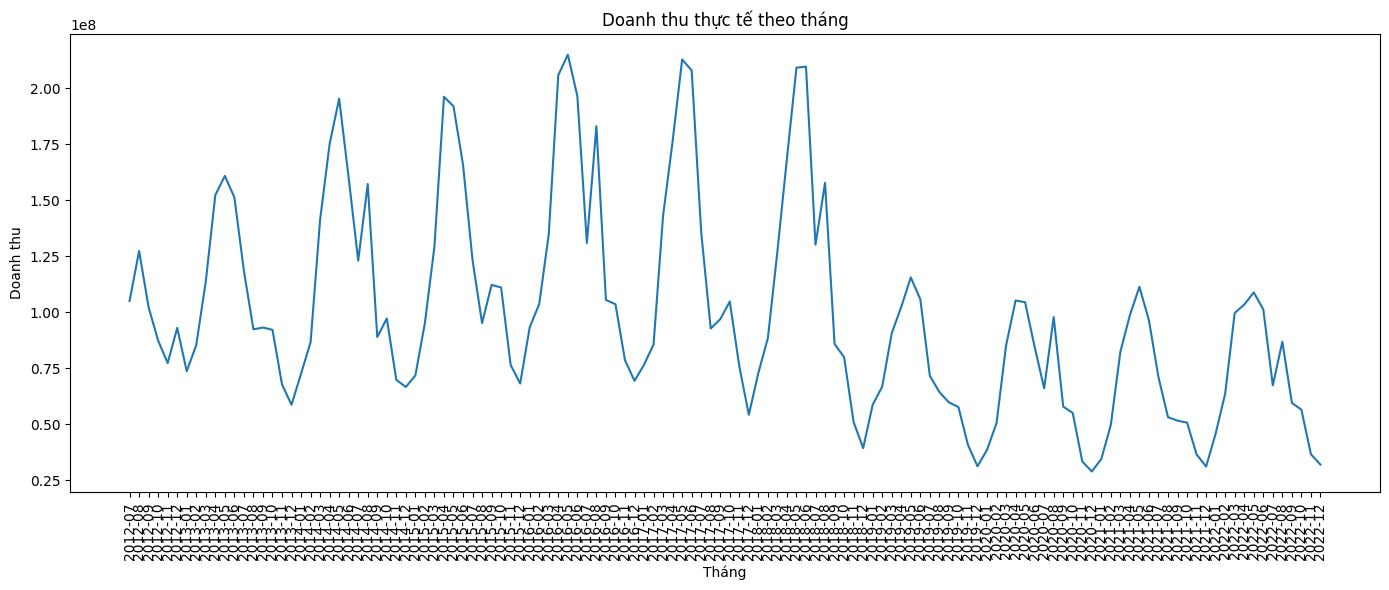

In [ ]:
# Biểu đồ doanh thu theo tháng
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["monthly_revenue"]
)

plt.title("Doanh thu thực tế theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

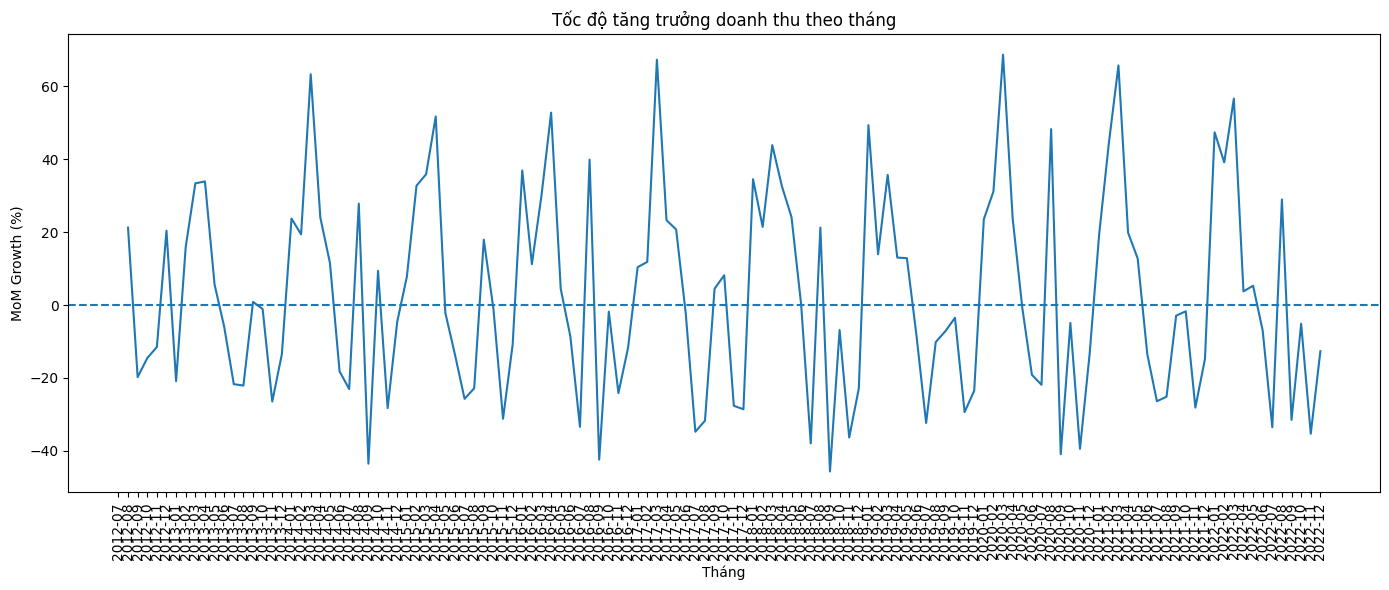

In [ ]:
# biểu đồ MoM
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["month"].astype(str),
    monthly_revenue["mom_growth"]
)

plt.axhline(0, linestyle="--")

plt.title("Tốc độ tăng trưởng doanh thu theo tháng")
plt.xlabel("Tháng")
plt.ylabel("MoM Growth (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()